# K-Nearest Neighbors
(by Tevfik Aytekin)


K-nearest neighbors is a non-parametric method which can be used for both classification and regression.

### K-NN Classification

A new instance is classified according to its k nearest neighbors. Consider the example below where there are 2 classes of objects:

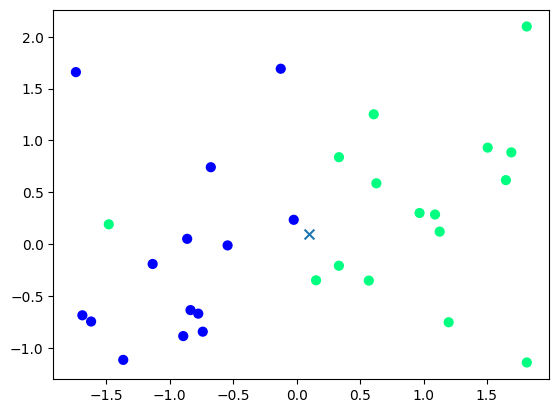

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn import linear_model
# test test

X, y = make_classification(n_samples = 30,n_features=2, n_redundant=0, n_informative=1, class_sep=1,
                             n_clusters_per_class=1, random_state=1, n_classes=2)

#plt.figure(figsize=(4.5,4));
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter');
plt.scatter(0.1,0.1, marker='x', s= 50);


If k = 3, then the object shown with an 'x' will be classified as "green" since the majority class among the set of 3 nearest neighbors of 'x' is "green".

We can also show the decision boundaries (also called Voronoi diagram) for the above example (for k=1 and k=2) as follows:

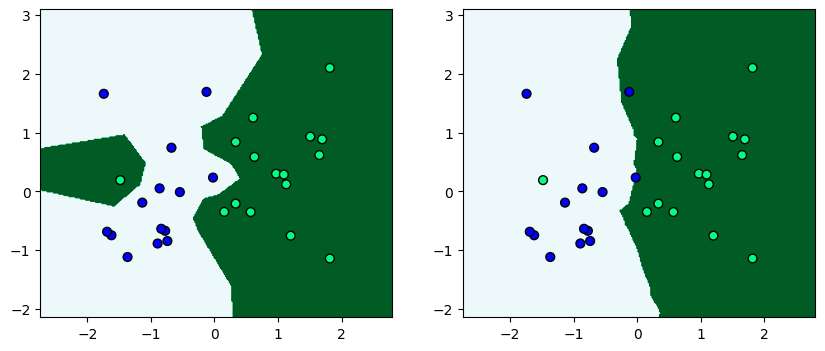

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

from sklearn.datasets import make_classification
fig, ax = plt.subplots(1,2,figsize=(10,4));

clf = KNeighborsClassifier(n_neighbors=1)
# You can play with n_neighbors
clf.fit(X, y)
plot_step = 0.02
n_classes = 2
plot_colors = "rgb"

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = ax[0].contourf(xx, yy, Z, cmap="BuGn")

ax[0].scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter',edgecolor='black');


clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X, y)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = ax[1].contourf(xx, yy, Z, cmap="BuGn")

ax[1].scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter',edgecolor='black');


### iris dataset

In [ ]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris = pd.read_csv(url, names=names)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


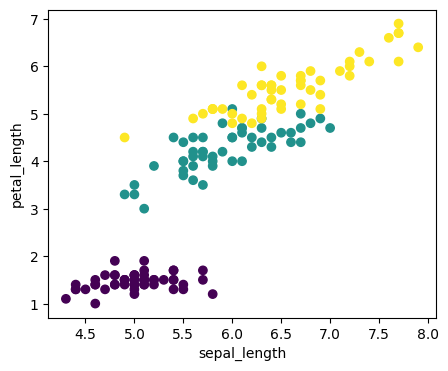

In [ ]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
colors = le.transform(iris.species.values)

x=0;y=2;
# change x and y values to see scatter plots of different features

plt.figure(figsize=(5, 4))
plt.scatter(iris.iloc[:, x], iris.iloc[:, y],c=colors)
#plt.colorbar(ticks=[0, 1, 2])
plt.xlabel(names[x]);
plt.ylabel(names[y]);


In [ ]:
from sklearn.model_selection import train_test_split
X = iris.iloc[:,0:3]
y = iris.iloc[:,4]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=4)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler = scaler.fit(X_train)
X_train = scaler.transform(X_train)
# test set should be scaled with the scaler trained on the training set.
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(X_train, y_train);
y_pred = clf.predict(X_test)
print(y_test.values)
print(y_pred)

['Iris-virginica' 'Iris-setosa' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-virginica']
['Iris-virginica' 'Iris-setosa' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-virginica']


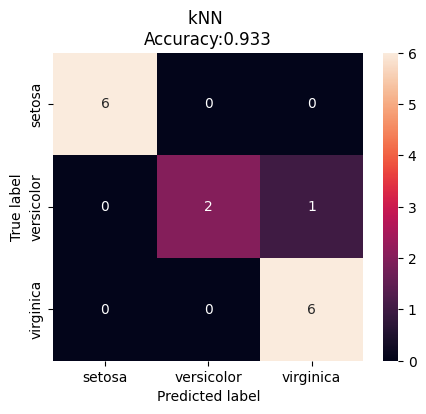

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                     index = ['setosa','versicolor','virginica'],
                     columns = ['setosa','versicolor','virginica'])

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True)
plt.title('kNN \nAccuracy:{0:.3f}'.format(accuracy_score(y_test, y_pred)))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



In [ ]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         6
Iris-versicolor       1.00      0.67      0.80         3
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.93        15
      macro avg       0.95      0.89      0.91        15
   weighted avg       0.94      0.93      0.93        15



### K-NN Regression

(26, 1) (26,)
(3, 1) (3,)


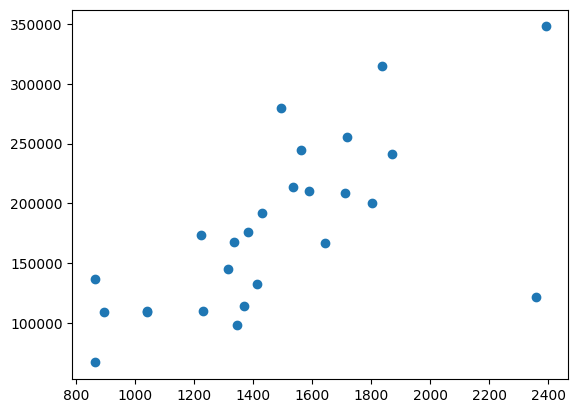

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

house = pd.read_csv("train.csv")
house2 = house[(house.GrLivArea < 4000) & (house.SalePrice < 400000)]
house2 = house2.sample(frac=0.02)
X = house2[['GrLivArea']]
y = house2['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.1, random_state=1)
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)
plt.scatter(X_train, y_train)

In the following code, you can play with the n_neighbors parameter (for example from 1 to 10). Smaller values leads to overfitting and larger values produces a smoother regression line. The best value should be determined with cross validation.

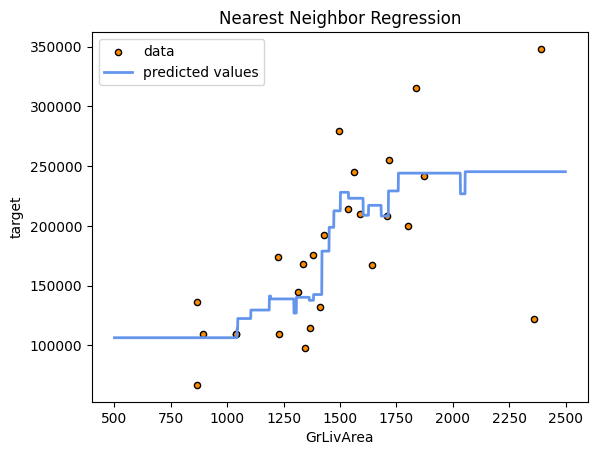

Train MAE: 32241.853846153845


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Fit regression model
regr = KNeighborsRegressor(n_neighbors=5)
#play with n_neighbors
regr.fit(X_train, y_train)

# Predict
X_test_line = np.arange(500, 2500, 1)[:, np.newaxis]
y_pred_line = regr.predict(X_test_line)
y_pred = regr.predict(X_train)

# Plot the results
plt.figure()
plt.scatter(X_train, y_train, s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(X_test_line, y_pred_line, color="cornflowerblue",
         label="predicted values", linewidth=2)
plt.xlabel("GrLivArea")
plt.ylabel("target")
plt.title("Nearest Neighbor Regression")
plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error
print("Train MAE:", mean_absolute_error(y_train, y_pred))


In [ ]:
# Run Regression with top correlated 10 attributes with SalePrice
from sklearn.metrics import mean_squared_log_error
def kaggle_score(y_true,y_pred):
    return np.sqrt(mean_squared_log_error(y_true, y_pred));
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

cors = house.corr(numeric_only=True);
top10 = cors.loc[:, "SalePrice"].sort_values(ascending = False).head(11)
top10 = top10.index.values.tolist()
top10.pop(0)

X = house.loc[:,top10]
y = house.loc[:,'SalePrice']
X = X.astype(float)


mae, kaggle, mape = [], [], []
for i in range(1,10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

    scaler = scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    # test set should be scaled with the scaler trained on the training set.
    X_test = scaler.transform(X_test)


    regr = KNeighborsRegressor(n_neighbors=5)
    model = regr.fit(X_train, y_train)

    test_predictions = model.predict(X_test)
    mae.append(mean_absolute_error(y_test, test_predictions))
    kaggle.append(kaggle_score(y_test, np.abs(test_predictions)))
    mape.append(mean_absolute_percentage_error(y_test, test_predictions))

print("Test MAE:", np.mean(mae))
print("Test Kaggle-Score:", np.mean(kaggle))
print("Test MAPE:", np.mean(mape))

print(top10)


Test MAE: 22232.461339421614
Test Kaggle-Score: 0.17524528033981945
Test MAPE: 12.926434151011676
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


### Curse of Dimensionality

Using more feature might not give better results always.

In [ ]:
X = house.loc[:,'MSSubClass':'SaleCondition']
y = house.loc[:,'SalePrice']
X = pd.get_dummies(X)
mae, kaggle, mape = [], [], []
for i in range(1,10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
    X_train = X_train.fillna(X_train.mean())
    X_test = X_test.fillna(X_test.mean())

    scaler = scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    # test set should be scaled with the scaler trained on the training set.
    X_test = scaler.transform(X_test)


    regr = KNeighborsRegressor(n_neighbors=5)

    model = regr.fit(X_train, y_train)
    test_predictions = model.predict(X_test)
    mae.append(mean_absolute_error(y_test, test_predictions))
    kaggle.append(kaggle_score(y_test, np.abs(test_predictions)))
    mape.append(mean_absolute_percentage_error(y_test, test_predictions))

print("Test MAE:", np.mean(mae))
print("Test Kaggle-Score:", np.mean(kaggle))
print("Test MAPE:", np.mean(mape))


Test MAE: 25390.018417047184
Test Kaggle-Score: 0.19638241834793307
Test MAPE: 14.067923277476213


In [ ]:
X.shape

(1460, 287)

It is always good to compare your model's performance with a baseline.

In [ ]:
np.mean(np.abs((y_test- np.mean(y_train))))

np.float64(59167.17706052834)

In order to make sense of the error, let us look at the distribution of sale prices.

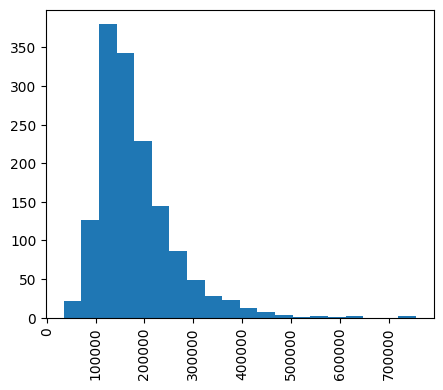

In [ ]:
plt.figure(figsize=(5,4))
plt.xticks(rotation=90)
plt.hist(house.SalePrice, 20);

### Scaling and centering


#### min-max scaling

$$
x_i = \frac{x_i - x_{min}}{x_{max}-x_{min}}
$$

where $x$ is a feature vector (a column of the data matrix), $x_i$ is the original value, $x_{min}$ is the minimum and $x_{max}$ is the maximum value in $x$.

In [ ]:
# create a DataFrame
df = pd.DataFrame([[100, 1990, 100000],
                  [120, 2002, 150000],
                  [90, 2012, 120000]],
                 index = [5, 10,15],
                 columns = ["area","built","price"])
df

,area,built,price
5,100,1990,100000
10,120,2002,150000
15,90,2012,120000


In [ ]:
from sklearn.preprocessing import MinMaxScaler
#Normally, we do not scale the target feature.
df = df.drop(columns=["price"])
scaler = MinMaxScaler()
scaler = scaler.fit(df)
print(scaler.data_max_)
print(scaler.data_min_)

[ 120. 2012.]
[  90. 1990.]


In [ ]:
print(scaler.transform(df))

[[0.33333333 0.        ]
 [1.         0.54545455]
 [0.         1.        ]]


#### Standard scaling

$$
x_i = \frac{x_i - \bar{x}}{s_x}
$$

where $x$ is a feature vector (a column of the data matrix), $x_i$ is the original value, $\bar{x}$ is the mean of $x$ and $s_x$ is the std of $x$.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler = scaler.fit(df)
print(scaler.transform(df))

[[-0.26726124 -1.26012384]
 [ 1.33630621  0.07412493]
 [-1.06904497  1.18599891]]


## Distance metrics

Different distance metrics can be used to define the distance between individual data points. Sklearn's [DistanceMetric](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html#sklearn.metrics.DistanceMetric) class defines various distance metrics.

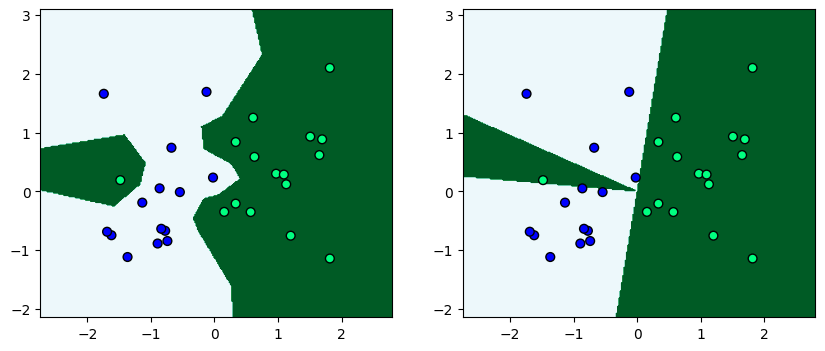

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

from sklearn.datasets import make_classification
fig, ax = plt.subplots(1,2,figsize=(10,4));
X, y = make_classification(n_samples = 30,n_features=2, n_redundant=0, n_informative=1, class_sep=1,
                             n_clusters_per_class=1, random_state=1, n_classes=2)
clf = KNeighborsClassifier(n_neighbors=1)
# You can play with n_neighbors
clf.fit(X, y)
plot_step = 0.02
n_classes = 2
plot_colors = "rgb"

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))




Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = ax[0].contourf(xx, yy, Z, cmap="BuGn")

ax[0].scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter',edgecolor='black');


clf = KNeighborsClassifier(n_neighbors=1, metric='cosine')
clf.fit(X, y)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = ax[1].contourf(xx, yy, Z, cmap="BuGn")

ax[1].scatter(X[:, 0], X[:, 1], marker='o', c=y, s=40, cmap='winter',edgecolor='black');


When you use the Euclidean distance (the default in scikit-learn), the K-NN algorithm calculates the straight-line distance between points. The resulting Voronoi diagram consists of polygonal regions where the decision boundaries are perpendicular bisectors between the points. It takes both the direction and the magnitude (position in space) into account.

However, when you change the metric to Cosine distance, the algorithm calculates the angle between the points, treating them as vectors originating from the origin (0,0). Cosine distance completely ignores the magnitude (length) of the vectors and only cares about their direction.

Visually, this changes the Voronoi diagram significantly:

- Instead of enclosed polygonal regions, the decision boundaries for the cosine metric will look like rays or straight lines emanating from the origin.
- Any two points that lie on the same line starting from the origin will have a cosine distance of 0, meaning they are considered "identical" by the algorithm, regardless of how far apart they actually are in the 2D space.
- As a result, the space is divided into angular sectors rather than spatial clusters.

### Cosine Similarity for Document Similarity

Cosine similarity is a powerful metric for determining how similar two documents are, especially when documents are represented as numerical vectors (e.g., using word counts or TF-IDF values). It measures the cosine of the angle between two non-zero vectors. A cosine similarity close to 1 indicates that the documents are very similar, while a value close to 0 suggests dissimilarity.

**Why is it useful for documents?**

1.  **Ignores document length:** Unlike Euclidean distance, cosine similarity is not affected by the length of the documents. If two documents discuss the same topic but one is much longer, their Euclidean distance might be large, but their cosine similarity would still be high because the angle between their word-vector representations would be small.
2.  **Focuses on direction:** It captures the 'direction' or 'topic' of the document. If documents use similar words with similar frequencies, their vectors will point in roughly the same direction, resulting in high cosine similarity.

Documents are typically converted into vectors using methods like Bag-of-Words (word counts) or TF-IDF (Term Frequency-Inverse Document Frequency), where each dimension of the vector corresponds to a unique word in the vocabulary.

### Cosine Similarity and Cosine Distance Formula

**Cosine Similarity** measures the cosine of the angle between two non-zero vectors in a multi-dimensional space. It is calculated using the following formula:

$$ \text{Cosine Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}} $$

Where:
*   $A$ and $B$ are two vectors (e.g., document vectors).
*   $A \cdot B$ is the dot product of vectors $A$ and $B$.
*   $\|A\|$ is the Euclidean norm (magnitude) of vector $A$.
*   $\|B\|$ is the Euclidean norm (magnitude) of vector $B$.
*   $A_i$ and $B_i$ are the components of vectors $A$ and $B$ respectively.
*   $n$ is the number of dimensions in the vectors.

**Interpretation of Cosine Similarity:**
*   A value of 1 means the vectors are identical in direction (angle of 0 degrees).
*   A value of 0 means the vectors are orthogonal (angle of 90 degrees), indicating no similarity.
*   A value of -1 means the vectors are exactly opposite (angle of 180 degrees).

**Cosine Distance** is simply calculated as 1 minus the cosine similarity. This transforms the similarity score into a distance metric:

$$ \text{Cosine Distance}(A, B) = 1 - \text{Cosine Similarity}(A, B) $$

**Interpretation of Cosine Distance:**
*   A value of 0 means the vectors are identical in direction (maximum similarity, minimum distance).
*   A value of 1 means the vectors are orthogonal (no similarity, moderate distance).
*   A value of 2 means the vectors are exactly opposite (minimum similarity, maximum distance).

Cosine distance is particularly useful when the magnitude of the vectors is not as important as their orientation, such as in document similarity where document length variations are common.

In [1]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define two simple vectors (e.g., representing short documents)
A = np.array([1, 1, 0, 1]) # Document A: 'cat dog' (assuming 1 for presence, 0 for absence)
B = np.array([0, 1, 1, 1]) # Document B: 'dog mouse' (assuming 1 for presence, 0 for absence)

print(f"Vector A: {A}")
print(f"Vector B: {B}")

# Step 1: Calculate the dot product (A . B)
dot_product = np.dot(A, B)
print(f"\nDot Product (A . B): {dot_product}")

# Step 2: Calculate the magnitude (Euclidean norm) of each vector
magnitude_A = np.linalg.norm(A)
magnitude_B = np.linalg.norm(B)
print(f"Magnitude of A (||A||): {magnitude_A:.2f}")
print(f"Magnitude of B (||B||): {magnitude_B:.2f}")

# Step 3: Calculate Cosine Similarity
cosine_sim = dot_product / (magnitude_A * magnitude_B)
print(f"Cosine Similarity: {cosine_sim:.2f}")

# Step 4: Calculate Cosine Distance
cosine_dist = 1 - cosine_sim
print(f"Cosine Distance: {cosine_dist:.2f}")

# Verification using scikit-learn
# Reshape arrays for sklearn's cosine_similarity function
A_reshaped = A.reshape(1, -1)
B_reshaped = B.reshape(1, -1)

sk_cosine_sim = cosine_similarity(A_reshaped, B_reshaped)[0][0]
print(f"\nScikit-learn Cosine Similarity: {sk_cosine_sim:.2f}")

sk_cosine_dist = 1 - sk_cosine_sim
print(f"Scikit-learn Cosine Distance: {sk_cosine_dist:.2f}")

Vector A: [1 1 0 1]
Vector B: [0 1 1 1]

Dot Product (A . B): 2
Magnitude of A (||A||): 1.73
Magnitude of B (||B||): 1.73
Cosine Similarity: 0.67
Cosine Distance: 0.33

Scikit-learn Cosine Similarity: 0.67
Scikit-learn Cosine Distance: 0.33


## Flexibility of knn

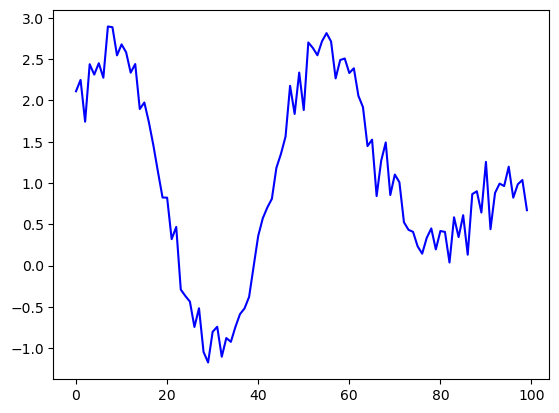

In [ ]:
n = 100
X = np.linspace(0, 5, n)
y = 1 + np.sin(3*X) + np.cos(2*X) + np.random.normal(0, 0.2, n)
plt.plot(y, color="b")

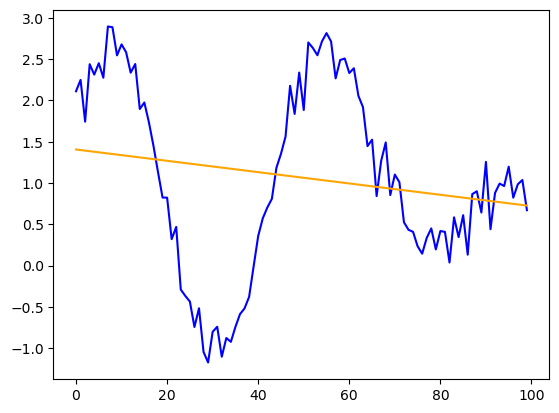

In [ ]:
X = X.reshape(-1,1)
lm = linear_model.LinearRegression().fit(X,y)
preds = lm.predict(X)
plt.plot(y, color="blue")
plt.plot(preds, color="orange")

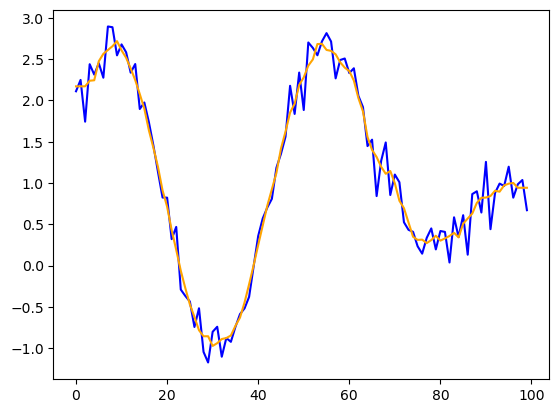

In [ ]:
X = X.reshape(-1,1)
knn = KNeighborsRegressor().fit(X,y)
preds = knn.predict(X)
plt.plot(y, color="blue")
plt.plot(preds, color="orange")

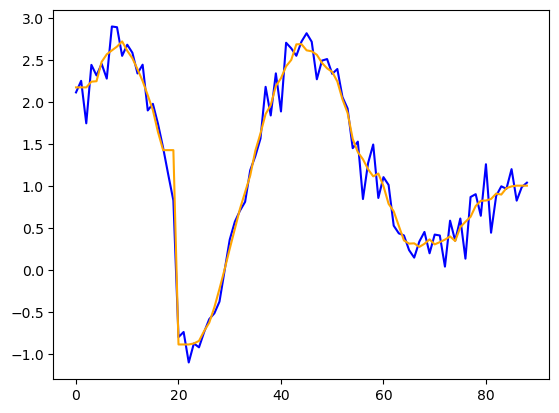

In [ ]:
X = np.vstack((X[0:20], X[30:-1]))
y = np.hstack((y[0:20], y[30:-1]))
knn = KNeighborsRegressor().fit(X,y)
preds = knn.predict(X)
plt.plot(y, color="blue")
plt.plot(preds, color="orange")